In [141]:
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

def test(model, X, y):
    preds = model.predict(X)

    cf = confusion_matrix(y, preds)
    sns.heatmap(cf, annot=True, fmt="d")

    print(preds)
    return classification_report(y, preds, zero_division=1)

# OR

In [135]:
from sklearn.linear_model import LogisticRegression

OR_model = LogisticRegression(penalty=None)


X = [[0,0], [0,1], [1,0], [1,1]]
y_OR = [0, 1, 1, 1]

OR_model.fit(X, y_OR)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


[0 1 1 1]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



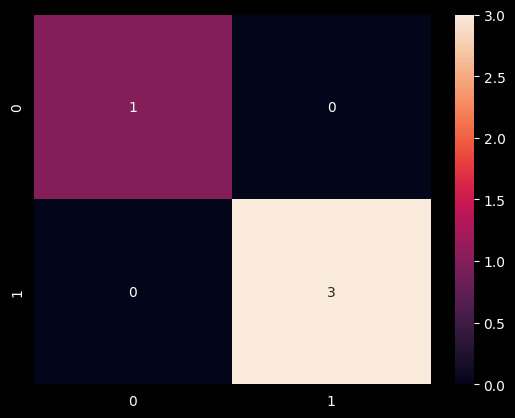

In [136]:
cr = test(OR_model, X, y_OR)
print(cr)

# XOR

In [137]:
from sklearn.linear_model import LogisticRegression

XOR_model = LogisticRegression(penalty=None)


X = [[0,0], [0,1], [1,0], [1,1]]
y_XOR = [0, 1, 1, 0]

XOR_model.fit(X, y_XOR)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


[0 0 0 0]
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       1.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.75      0.50      0.33         4
weighted avg       0.75      0.50      0.33         4



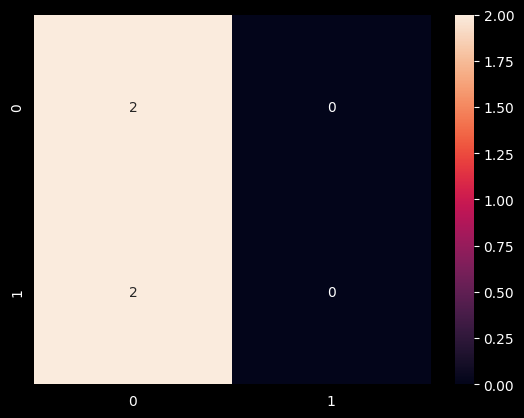

In [138]:
cr = test(XOR_model, X, y_XOR)
print(cr)

# Perceptron

In [139]:
import torch
import torch.nn as nn
import torch.optim as optim

X = torch.tensor([[0,0], [0,1], [1,0], [1,1]], dtype=torch.float32)
# y = torch.tensor([[0], [1], [1], [0]], dtype=torch.float32)

y = torch.tensor([[0], [1], [1], [1]], dtype=torch.float32)  # OR

class Percrepton(nn.Module):
    def __init__(self):
        super(Percrepton, self).__init__()
        self.output = nn.Linear(2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.output(x))
        return x

model = Percrepton()


criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.25)

epochs = 5000

for epoch in range(epochs):
    predictions = model(X)
    loss = criterion(predictions, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

model.eval()
output = model(X)

output

Epoch [1000/5000], Loss: 0.0140
Epoch [2000/5000], Loss: 0.0063
Epoch [3000/5000], Loss: 0.0040
Epoch [4000/5000], Loss: 0.0029
Epoch [5000/5000], Loss: 0.0023


tensor([[0.0714],
        [0.9556],
        [0.9556],
        [0.9998]], grad_fn=<SigmoidBackward0>)

In [140]:
np_pred = output.detach().numpy()
preds = np.round(np_pred)
print(preds)
# print(classification_report(preds, y_XOR, zero_division=1))
print(classification_report(preds, y_OR, zero_division=1))

[[0.]
 [1.]
 [1.]
 [1.]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

